
Step size h = 0.01
Euler coefficient matrix:
[[ 1.    0.01]
 [-0.01  1.  ]]
Eigenvalues: [1.+0.01j 1.-0.01j]
Magnitudes: [1.00005 1.00005]
Solution may not be Entirely Stable ;)

Step size h = 0.02
Euler coefficient matrix:
[[ 1.    0.02]
 [-0.02  1.  ]]
Eigenvalues: [1.+0.02j 1.-0.02j]
Magnitudes: [1.00019998 1.00019998]
Solution may not be Entirely Stable ;)

Step size h = 0.03
Euler coefficient matrix:
[[ 1.    0.03]
 [-0.03  1.  ]]
Eigenvalues: [1.+0.03j 1.-0.03j]
Magnitudes: [1.0004499 1.0004499]
Solution may not be Entirely Stable ;)

Step size h = 0.05
Euler coefficient matrix:
[[ 1.    0.05]
 [-0.05  1.  ]]
Eigenvalues: [1.+0.05j 1.-0.05j]
Magnitudes: [1.00124922 1.00124922]
Solution may not be Entirely Stable ;)

Step size h = 0.1
Euler coefficient matrix:
[[ 1.   0.1]
 [-0.1  1. ]]
Eigenvalues: [1.+0.1j 1.-0.1j]
Magnitudes: [1.00498756 1.00498756]
Solution may not be Entirely Stable ;)

Step size h = 0.2
Euler coefficient matrix:
[[ 1.   0.2]
 [-0.2  1. ]]
Eigenvalues: [1.+0

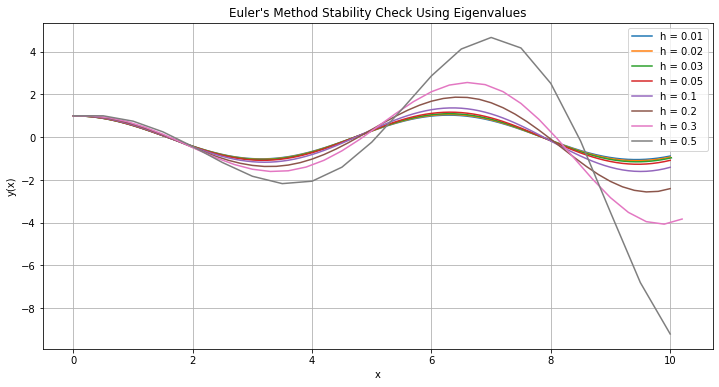

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# spring constant thing
k = 1.0

# interval + initial conditions
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0

# h values to test
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

# make the coefficient/system matrix from the oscillator
A = np.array([[0.0, 1.0],
              [-k, 0.0]])

plt.figure(figsize=(12, 6))

for h in h_values:
    # this is the Euler coefficient/update matrix
    M = np.eye(2) + h * A

    # built-in eigenvalue function 
    eigvals = np.linalg.eigvals(M)

    # magnitudes of the eigenvalues
    mags = np.abs(eigvals)

    print(f"\nStep size h = {h}")
    print("Euler coefficient matrix:")
    print(M)
    print("Eigenvalues:", eigvals)
    print("Magnitudes:", mags)

    # stability check:
    if np.any(mags > 1):
    print("Solution may not be Entirely Stable")
    else:
    print("Solution is Stable")
    
    # now simulate the numerical solution
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler loop
    for i in range(1, len(x_values)):
        current_state = np.array([y_values[i - 1], v_values[i - 1]])

        # use the matrix form from the slides 
        next_state = M @ current_state

        y_values[i] = next_state[0]
        v_values[i] = next_state[1]

    # plot position only so the graph does not get too insane
    plt.plot(x_values, y_values, label=f"h = {h}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Euler's Method Stability Check Using Eigenvalues")
plt.legend()
plt.grid(True)
plt.show()

Euler’s Method is unstable for this system because the eigenvalues have magnitude greater than 1. Larger step sizes make the instability worse, which matches the behavior seen in the plots.